In [64]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
%cd /content/
%rm -rf CS-5137-Deep-Learning

!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync
%cd homework3

downloading uv 0.9.7 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
/content
Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 1097, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 1097 (delta 112), reused 173 (delta 63), pack-reused 875 (from 1)
Receiving objects: 100% (1097/1097), 171.44 MiB | 11.93 MiB/s, done.
Resolving deltas: 100% (295/295), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 82 packages in 0.78ms
Installed 76 packages in 426ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==

In [68]:
!uv run -m src.train \
    --data_root ./data --val_ratio 0.2 \
    --num_workers 2 \
    --cache_rate 1 \
    --epochs 200 --batch_size 3 \
    --loss bce_dice --lr 3e-4 --optimizer adam \
    --use_green_channel \
    --up_mode bilinear \
    --base_channels 64 --depth 3 \
    --early_stopping \
    --early_stopping_patience 10 \
    --save_dir checkpoints --save_plots_path results/predictions \
    --device cuda

Loading dataset: 100% 64/64 [00:01<00:00, 43.59it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 63.47it/s]
Epoch 10/200 - Train Loss: 1.5393, Train Dice: 0.7788, Train IoU: 0.6410 | Val Loss: 0.1843, Val Dice: 0.7755, Val IoU: 0.6367
Epoch 20/200 - Train Loss: 1.3971, Train Dice: 0.7983, Train IoU: 0.6669 | Val Loss: 0.1601, Val Dice: 0.8058, Val IoU: 0.6772
Epoch 30/200 - Train Loss: 1.3681, Train Dice: 0.8031, Train IoU: 0.6735 | Val Loss: 0.1601, Val Dice: 0.8038, Val IoU: 0.6744
Epoch 40/200 - Train Loss: 1.3739, Train Dice: 0.8020, Train IoU: 0.6717 | Val Loss: 0.1591, Val Dice: 0.8063, Val IoU: 0.6778
=> Early stopping at epoch 41
Training time: 1329.35s | (best val dice = 0.8079)
Model saved to checkpoints/unet_new/best_model.pth


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_loss(loss_df, save_dir):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend()

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend()

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend()

    plt.tight_layout()
    # plt.savefig(os.path.join(save_dir, 'train_curve.png'))
    plt.show()

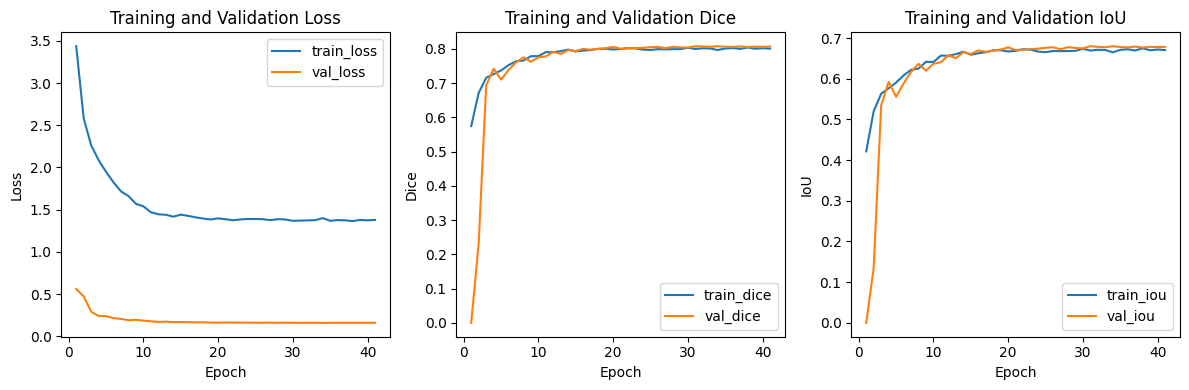

In [71]:
history_df = pd.read_csv('checkpoints/training_history.csv')
plot_loss(history_df, 'checkpoints')

# Download weights

In [79]:
from google.colab import files
%cd checkpoints
!zip -r checkpoints.zip *
files.download('checkpoints.zip')

/content/CS-5137-Deep-Learning/homework3/checkpoints/unet_new
updating: best_model.pth (deflated 8%)
updating: training_history.csv (deflated 51%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>